프로젝트명: EDA기반 타이타닉 생존율 예측
1. 데이터 구조 이해
2. 기초 통계 확인
3. 상관관계 확인
4. 시각화 인사이트 도출
5. 모델 설게 전 변수 선택 근거

### STEP#1 - 라이브러리 임포트 +  데이터 로드

In [42]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 한글 폰트 관련
from matplotlib import rc
path = "../malgun.ttf"
font_name = fm.FontProperties(fname=path).get_name()
rc('font', family=font_name)
plt.rc('font', family="Malgun Gothic")

In [43]:
train = pd.read_csv("../data/titanic/train.csv")  # 학습데이터 - 정답이 포함되어 있음( Survived )
test = pd.read_csv("../data/titanic/test.csv")    # 평가데이터 - 정답 미포함

print(f'train.shape = {train.shape}\ntest.shape = {test.shape}')
# train = train.iloc[:,:-1].values
# X

train.shape = (891, 12)
test.shape = (418, 11)


In [44]:
train.shape # (891, 12)

(891, 12)

In [45]:
test.shape  # (418, 11)

(418, 11)

In [46]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [47]:
train.drop(columns=['Name','Sex', 'Cabin', 'Embarked', 'Ticket'], inplace=True)
train.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare
0              1         0       3  22.0      1      0   7.2500
1              2         1       1  38.0      1      0  71.2833
2              3         1       3  26.0      0      0   7.9250
3              4         1       1  35.0      1      0  53.1000
4              5         0       3  35.0      0      0   8.0500
..           ...       ...     ...   ...    ...    ...      ...
886          887         0       2  27.0      0      0  13.0000
887          888         1       1  19.0      0      0  30.0000
888          889         0       3   NaN      1      2  23.4500
889          890         1       1  26.0      0      0  30.0000
890          891         0       3  32.0      0      0   7.7500

[891 rows x 7 columns]>

In [48]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

In [49]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          714 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


### STEP#2 - 상관관계 분석

In [50]:
# Feature Engineering을 시작하기 전에 상관계수, 결측치를 확인해 보기 
train.corr()  # 문자열이 들어가 있어 처리가 안됨, 전처리를 하면서 문자열은 제거해야 함

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


### STEP#3 - 결측치/구조 확인
- 데이터셋에서 값이 누락된 '결측치(Missing Value, NA/Null)'는 분석 결과 왜곡을 막기 위해 필수적인 전처리 대상입니다

In [51]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64

In [52]:
train.info()
# 승객대비 나이가 맞지 않은 컬럼이 있음

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          714 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


### 성별 처리
성별은 남성과 여성으로 나눔. 이를 0과 1로 변경해 주자

In [53]:
train = pd.read_csv('../data/titanic/train.csv')
data_list = [train, test]
train['Sex'].head()

0      male
1    female
2    female
3    female
4      male
Name: Sex, dtype: str

In [54]:
# 남성 1, 여성 0 숫자로 매핑 - 범주형
for data in data_list:
  data['Sex'] = data['Sex'].astype('category').cat.codes
train['Sex'].head()

0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int8

### Age 처리
위에서 Age컬럼에 177개ㅐ의 결측치가 존재하였다<br>
이 결측치에 대해 여성에게는 여성 나이의 평균, 남성에게는 남성 나이의 평균으로 채운다

In [55]:
sex_mean = train.groupby('Sex')['Age'].mean()
sex_mean

Sex
0    27.915709
1    30.726645
Name: Age, dtype: float64

In [56]:
# 여성 평균
sex_mean[0]

np.float64(27.915708812260537)

In [57]:
# 남성 평균
sex_mean[1]

np.float64(30.72664459161148)

In [58]:
# Age 결츠치 처리
for data in data_list:
  data.loc[(data['Sex'] == 0) & (data['Age'].isnull()), 'Age'] = sex_mean[0]
  data.loc[(data['Sex'] == 1) & (data['Age'].isnull()), 'Age'] = sex_mean[1]
train.isnull().sum()  

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

```txt
Age를 카테고리화 하기
남자와 여자는 0, 1로 차이가 극명하게 나뉘는 값이지만 요금이나 나이의 경우
20과 30의 차리가 10이라고 해서 극명하게 나뉘는 값이 아니다.
이를 전체적인 범주에 맞게 맞워주기 위해 카테고리화 한다.

먼저 Age를 4개 구간으로 나누어 Age Range 컬럼에 저장해 준다.
```

In [59]:
# ✅ 1) 나이를 5개의 구간으로 나누기 (카테고리화)
# pd.cut(컬럼, 5)
# → Age 값을 최소~최대 범위 기준으로 5등분하여 구간 생성
train['AgeRange'] = pd.cut(train['Age'], 5)

# 예:
# (0, 16], (16, 32], (32, 48], (48, 64], (64, 80]
# 이런 식으로 연령대 구간이 자동 생성됨

# ✅ 2) AgeRange별 Survived 평균 구하기
# groupby(['AgeRange']) → 나이 구간별로 묶기
# .mean() → 각 구간에서 Survived 평균 계산
# (Survived는 0 또는 1이므로 평균 = 생존률)

train[['AgeRange', 'Survived']].groupby(['AgeRange']).mean()

,Survived
AgeRange,
"(0.34, 16.336]",0.550000
"(16.336, 32.252]",0.344168
"(32.252, 48.168]",0.404255
"(48.168, 64.084]",0.434783
"(64.084, 80.0]",0.090909


In [60]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeRange
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,"(16.336, 32.252]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,"(32.252, 48.168]"
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,"(16.336, 32.252]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,"(32.252, 48.168]"
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,"(32.252, 48.168]"


In [61]:
# 16, 32, 48, 64값들을 기준으로 카테고리화 하면 된다.
# 카테고리화가 되면 Age,Range 컬럼은 삭제 하기
for data in data_list:    
    data.loc[ data['Age'] <= 16, 'Age'] = 0
    data.loc[(data['Age'] > 16) & (data['Age'] <= 32), 'Age'] = 1
    data.loc[(data['Age'] > 32) & (data['Age'] <= 48), 'Age'] = 2
    data.loc[(data['Age'] > 48) & (data['Age'] <= 64), 'Age'] = 3
    data.loc[ data['Age'] > 64, 'Age'] = 4
train.drop('AgeRange', inplace=True, axis=1)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,1.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,1.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,2.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,2.0,0,0,373450,8.0500,NaN,S


### STEP#4 - 데이터 전처리 시작

Name 처리<br>
탑승객들의 이름 앞을 추출해 보면 Mr, Mrs, Miss등의 명칭을 가지고 있다.<br>
이름 전체를 사용하는 것은 생존자 예측에 큰 영향을 주지 않을 것이다<br>

In [62]:
# 정규식: 앞에 공백 한칸
# A-Z 또는 a-z가 1개 이상 반복되는 문자열을 캡처(Mr, Mrs, Dr 등)
# 뒤에 마침표가 오는 패턴을 찾아서 반영
train['Title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Tile값의 빈도수 확인
# 각 호칭이 데이터에 몇 명씩 존재하는지 카운트
train['Title'].value_counts()

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
C:\Users\kosmo\AppData\Local\Temp\ipykernel_14508\87318395.py:4: SyntaxWarning: invalid escape sequence '\.'
  train['Title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

문자열 처리 기반 피처 엔지니어링<br>
단순히 주어진 컬럼만 사용하는 것이 아니라 문자열 속에 숨겨진 정보를 추출해서 새로운 변수로 사용이 가능함.<br>
```txt
Mr, Miss, Mrs, Master가 가장 많이 존재하고 나머지는 적게 존재 하므로 복잡도를 낮추기 위해서 
모두 'Other'로 통일해 본다
```

In [63]:
for data in data_list:
    data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    data['Title'] = data['Title'].replace(['Dr', 'Rev', 'Mlle', 'Major', 'Col', 'Countess',
                                        'Capt', 'Ms', 'Sir', 'Lady', 'Mme', 'Don', 'Jonkheer'], 'Other')
    # -> 범주형 -> 수치형
    data['Title_name'] = data['Title'].astype('category').cat.codes

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\kosmo\AppData\Local\Temp\ipykernel_14508\686705810.py:2: SyntaxWarning: invalid escape sequence '\.'
  data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [64]:
train[['Title', 'Survived']].groupby(['Title']).mean()

,Survived
Title,
Master,0.575000
Miss,0.697802
Mr,0.156673
Mrs,0.792000
Other,0.444444


Embarked 결측치인 행 찾기

In [65]:
embarked_null = train['Embarked'].isna()
print('결측 갯수 : ', embarked_null.sum())
train[embarked_null]

결측 갯수 :  2


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Title_name
61,62,1,1,"Icard, Miss. Amelie",0,2.0,0,0,113572,80.0,B28,NaN,Miss,1
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",0,3.0,0,0,113572,80.0,B28,NaN,Mrs,3


### STEP#5 - 불필요한 컬럼 제거

In [66]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    int8   
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  Title        891 non-null    str    
 13  Title_name   891 non-null    int8   
dtypes: float64(2), int64(5), int8(2), str(5)
memory usage: 85.4 KB


In [67]:
# 중복되는 불필요한 컬럼 지우기
train.drop(['Name', 'Title'], axis=1, inplace=True)
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_name
0,1,0,3,1,1.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,0,2.0,1,0,PC 17599,71.2833,C85,C,3
2,3,1,3,0,1.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,0,2.0,1,0,113803,53.1000,C123,S,3
4,5,0,3,1,2.0,0,0,373450,8.0500,NaN,S,2


SibSp, Parch 전처리<br>
SibSp는 함께 탑승한 형제자매, 배우자의 총합/ Parch는 함께 탑승한 부모, 자년의 총합임<br>
혼자 탑승한 탑승객과 그 외의 탑승객의 사망률에 차이가 있었기 떄문에 가족이라는 새로운 컬럼으로 묶음<br>

In [68]:
# ✅ FamilySize(가족 수) 파생변수 만들기
# - SibSp: 함께 탑승한 형제/자매/배우자 수
# - Parch: 함께 탑승한 부모/자녀 수
# - + 1 : 본인 1명을 포함해서 "총 가족 규모"로 만들기
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

# ❌ (원본 코드의 문제점)
# test의 FamilySize를 만들면서 train의 SibSp/Parch를 사용하고 있음
# → test 행 개수(418)와 train 행 개수(891)가 달라서
#   값이 섞이거나 NaN이 생기거나(인덱스 정렬 때문에) 잘못된 결과가 나올 수 있음

# ✅ 올바른 코드(수정)
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1


# ✅ 앞 5행을 출력해서 FamilySize가 정상 생성됐는지 확인
# - 새 컬럼 FamilySize가 추가되었는지
# - 값이 SibSp+Parch+1 계산대로 들어갔는지 확인
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_name,FamilySize
0,1,0,3,1,1.0,1,0,A/5 21171,7.2500,NaN,S,2,2
1,2,1,1,0,2.0,1,0,PC 17599,71.2833,C85,C,3,2
2,3,1,3,0,1.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,0,2.0,1,0,113803,53.1000,C123,S,3,2
4,5,0,3,1,2.0,0,0,373450,8.0500,NaN,S,2,1


<Axes: xlabel='FamilySize', ylabel='count'>

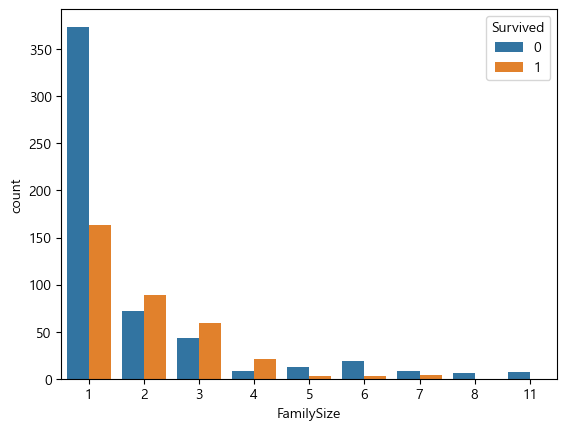

In [69]:
pd.pivot_table(train, index='FamilySize', values='Survived')
sns.countplot(data=train, x='FamilySize', hue='Survived')

In [70]:
train[['FamilySize', 'Survived']].groupby('FamilySize').mean()

,Survived
FamilySize,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


In [71]:
train.drop(['SibSp', 'Parch'], axis=1, inplace=True)
# test.drop(['SibSp', 'Parch'], axis=1, inplace=True)
train.head()

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Title_name,FamilySize
0,1,0,3,1,1.0,A/5 21171,7.2500,NaN,S,2,2
1,2,1,1,0,2.0,PC 17599,71.2833,C85,C,3,2
2,3,1,3,0,1.0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,0,2.0,113803,53.1000,C123,S,3,2
4,5,0,3,1,2.0,373450,8.0500,NaN,S,2,1


In [72]:
data_list

[     PassengerId  Survived  Pclass  Sex  Age            Ticket     Fare Cabin  \
 0              1         0       3    1  1.0         A/5 21171   7.2500   NaN   
 1              2         1       1    0  2.0          PC 17599  71.2833   C85   
 2              3         1       3    0  1.0  STON/O2. 3101282   7.9250   NaN   
 3              4         1       1    0  2.0            113803  53.1000  C123   
 4              5         0       3    1  2.0            373450   8.0500   NaN   
 ..           ...       ...     ...  ...  ...               ...      ...   ...   
 886          887         0       2    1  1.0            211536  13.0000   NaN   
 887          888         1       1    0  1.0            112053  30.0000   B42   
 888          889         0       3    0  1.0        W./C. 6607  23.4500   NaN   
 889          890         1       1    1  1.0            111369  30.0000  C148   
 890          891         0       3    1  1.0            370376   7.7500   NaN   
 
     Embarked 

<Axes: xlabel='Embarked', ylabel='count'>

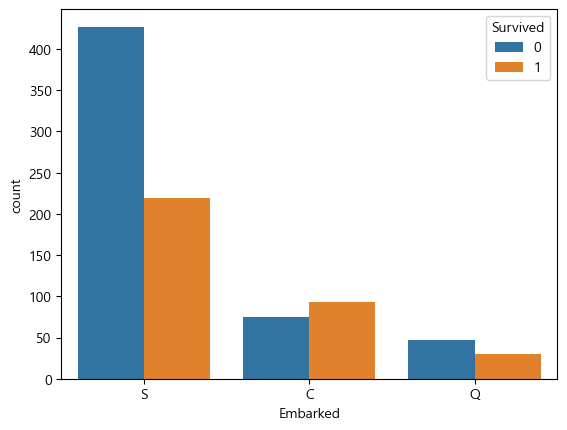

In [73]:
for data in data_list:
  # Embarker의 결측치를 'S'로 채움 -> 나중에 범주형이지만 수치형으로 변경함
  data['Embarked'] = data['Embarked'].fillna('S')
sns.countplot(data=train, x='Embarked', hue='Survived')

In [74]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int8   
 4   Age          891 non-null    float64
 5   Ticket       891 non-null    str    
 6   Fare         891 non-null    float64
 7   Cabin        204 non-null    str    
 8   Embarked     891 non-null    str    
 9   Title_name   891 non-null    int8   
 10  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(4), int8(2), str(3)
memory usage: 64.5 KB


In [75]:
train['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [76]:
em_mapping = {'S': 0, 'C': 1, 'Q': 2}
for data in data_list:
  data['Embarked'] = data['Embarked'].map(em_mapping)

In [77]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Title_name,FamilySize
0,1,0,3,1,1.0,A/5 21171,7.2500,NaN,0,2,2
1,2,1,1,0,2.0,PC 17599,71.2833,C85,1,3,2
2,3,1,3,0,1.0,STON/O2. 3101282,7.9250,NaN,0,1,1
3,4,1,1,0,2.0,113803,53.1000,C123,0,3,2
4,5,0,3,1,2.0,373450,8.0500,NaN,0,2,1


Cabin - 선실<br>
```txt
어떤 객실 번호가 존재하는지 확인해 본다.
Cabin데이터 특성 파악
결측치가 매우 많음
고유값이 매우 많음
실제로 객실 번호 보다는 객실 등급 문자(A,B,C,,)가 더 중요함. 
```

In [83]:
# 타이타닉에서 객실 번호 걸럼을 선택하고 각 고유값이 몇 번 나왔는지 카운트한 값임
# value_coiunts()는 기본적으로 NaN을 제외함
train['Cabin'].value_counts()

Cabin
7    687
2     59
1     47
3     33
4     32
0     15
5     13
6      4
8      1
Name: count, dtype: int64

```txt
특정 객실이 여러 명에게 기록되어 있음 -> 가족 단위 승객 가능성
동일 객실에 몇 명이 있었는지 확인 가능
1이면 단독 사용
2이상 이면 가족/동행 가능성 있음
```

In [79]:
# 만일 결측치를 포함한 값을 보고 싶다면
train['Cabin'].value_counts(dropna=False)

Cabin
NaN            687
G6               4
C23 C25 C27      4
B96 B98          4
F33              3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

In [80]:
# Cabin의 결측치(NaN)를 'N'으로 채움
# Cabin의 결측치가 많아서 그대로 두면 모델 학습이 불가능
for data in data_list:
  data['Cabin'] = data['Cabin'].fillna('N')
  # 첫글자 ( C, E, B, ,,, )는 객실 구역을 의미함.
  # 숫자는 세부 방 번호라 범주가 너무 많아서 구역 정보만 남김
  data['Cabin'] = data['Cabin'].apply(lambda x: x[0])
  data['Cabin'] = data['Cabin'].astype('category').cat.codes
train.head()

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Title_name,FamilySize
0,1,0,3,1,1.0,A/5 21171,7.2500,7,0,2,2
1,2,1,1,0,2.0,PC 17599,71.2833,2,1,3,2
2,3,1,3,0,1.0,STON/O2. 3101282,7.9250,7,0,1,1
3,4,1,1,0,2.0,113803,53.1000,2,0,3,2
4,5,0,3,1,2.0,373450,8.0500,7,0,2,1


Fare - 요금<br>
Fare도 Age 에서 한 것돠 같이 이미  숫자이지만 단순화를 위해 4개 구간으로 나눔<br>
즉 요금이 얼마였는지 그대로 쓰는 대신<br>
요금이 낮은편/ 중간/ 높은편 매우 높은 편<br>

In [ ]:
for data in data_list:
  data['Farerange'] = pd.cut(data['Fare'], 4)
train[['Farerange', 'Survived']].groupby(['Farerange']).mean()

,Survived
Farerange,
"(-0.003, 0.75]",0.368113
"(0.75, 1.5]",0.724138
"(1.5, 2.25]",0.666667
"(2.25, 3.0]",1.000000


요금 구간을 4개로 나눔<br>
128, 256, 384를 기준으로 나눔<br>

In [85]:
for data in data_list:    
    data.loc[data['Fare'] <= 128, 'Fare'] = 0
    data.loc[(data['Fare'] > 128) & (data['Fare'] <= 256), 'Fare'] = 1
    data.loc[(data['Fare'] > 256) & (data['Fare'] <= 384), 'Fare'] = 2
    data.loc[data['Fare'] > 384, 'Fare'] = 3

train.head()

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Title_name,FamilySize,Farerange
0,1,0,3,1,1.0,A/5 21171,0.0,7,0,2,2,"(-0.512, 128.082]"
1,2,1,1,0,2.0,PC 17599,0.0,2,1,3,2,"(-0.512, 128.082]"
2,3,1,3,0,1.0,STON/O2. 3101282,0.0,7,0,1,1,"(-0.512, 128.082]"
3,4,1,1,0,2.0,113803,0.0,2,0,3,2,"(-0.512, 128.082]"
4,5,0,3,1,2.0,373450,0.0,7,0,2,1,"(-0.512, 128.082]"


```txt
요금이 높은 구간일 수록 생존율이 높게 나오면
-> 돈을 많이 낸 승객이 더 많이 살았다 라는 패턴을 의심할 수 있다.

### STEP#6 - 최종 상관분석 결과 확인 + X/y 구성

### STEP#7- 여러 모델 교차검증 비교

KNN, Decision tree, Random Forestm, Gradient Boosting, GaussianNB, SVC